<a href="https://colab.research.google.com/github/justicec387-prog/Portfolio/blob/main/%22Institutional_Vendor_Risk_Optimizer_v2_ipynb%22_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Create Mock Vendor Data
np.random.seed(42)
vendors = ['Alo Health', 'Louboutin Logistics', 'Global Tech', 'NYC Supplies', 'SafeData Inc']
data = {
    'vendor_name': np.random.choice(vendors, 100),
    'contract_value': np.random.randint(10000, 150000, 100),
    'risk_score': np.random.randint(1, 11, 100),
    'expiration_date': [datetime.now() + timedelta(days=np.random.randint(-30, 365)) for _ in range(100)],
    'auto_renewal': np.random.choice([True, False], 100),
    'department': np.random.choice(['Legal', 'Supply Chain', 'IT', 'Operations'], 100)
}

df = pd.DataFrame(data)
df.to_csv('vendor_data_raw.csv', index=False)
print("Architect Alert: Raw Data Warehouse Created. Ready for Transformation.")


Architect Alert: Raw Data Warehouse Created. Ready for Transformation.


In [13]:
# View the top 5 rows of the warehouse
print(df.head())

    vendor_name  contract_value  risk_score            expiration_date  \
0  NYC Supplies           32662           3 2026-09-09 14:50:29.688643   
1  SafeData Inc           18392           3 2026-12-13 14:50:29.688670   
2   Global Tech           40535           4 2027-02-18 14:50:29.688758   
3  SafeData Inc          123569           7 2026-08-07 14:50:29.688777   
4  SafeData Inc           62256           4 2026-04-19 14:50:29.688783   

   auto_renewal  department  
0          True  Operations  
1          True          IT  
2         False       Legal  
3          True       Legal  
4          True  Operations  


In [14]:
# 1. Filter for 'Zombie' Contracts (Auto-renewal is True AND expiring soon)
# Let's define 'soon' as within the next 60 days
zombie_contracts = df[(df['auto_renewal'] == True) &
                      (df['expiration_date'] < (datetime.now() + timedelta(days=60)))]

# 2. Identify High-Risk / High-Value Vendors
# These are vendors with a Risk Score > 8 and a Contract Value > $100,000
high_stakes_vendors = df[(df['risk_score'] > 8) & (df['contract_value'] > 100000)]

# 3. Summary Statistics by Department
# This shows which department is carrying the most financial weight
dept_spend = df.groupby('department')['contract_value'].sum().sort_values(ascending=False)

print("--- ARCHITECT REPORT: CRITICAL AUDIT COMPLETE ---")
print(f"\n[!] ALERT: Found {len(zombie_contracts)} Zombie Contracts requiring immediate OGC review.")
print(f"\n[!] CRITICAL: Found {len(high_stakes_vendors)} High-Risk vendors with values exceeding $100k.")
print("\n--- SPEND BY DEPARTMENT ---")
print(dept_spend)


--- ARCHITECT REPORT: CRITICAL AUDIT COMPLETE ---

[!] ALERT: Found 9 Zombie Contracts requiring immediate OGC review.

[!] CRITICAL: Found 9 High-Risk vendors with values exceeding $100k.

--- SPEND BY DEPARTMENT ---
department
Legal           2789441
Operations      2160946
IT              2099363
Supply Chain    1929970
Name: contract_value, dtype: int64


/tmp/ipykernel_8215/669457528.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dept_spend.index, y=dept_spend.values, palette="viridis")


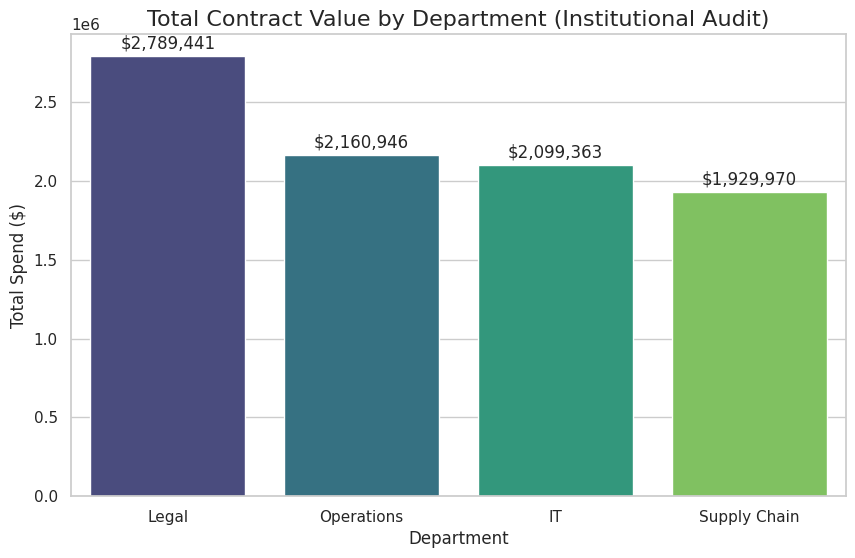

--- ARCHITECT ALERT: Executive Dashboard Rendered Successfully ---


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the Bar Chart
ax = sns.barplot(x=dept_spend.index, y=dept_spend.values, palette="viridis")

# Add Labels and Title
plt.title('Total Contract Value by Department (Institutional Audit)', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)

# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()
print("--- ARCHITECT ALERT: Executive Dashboard Rendered Successfully ---")

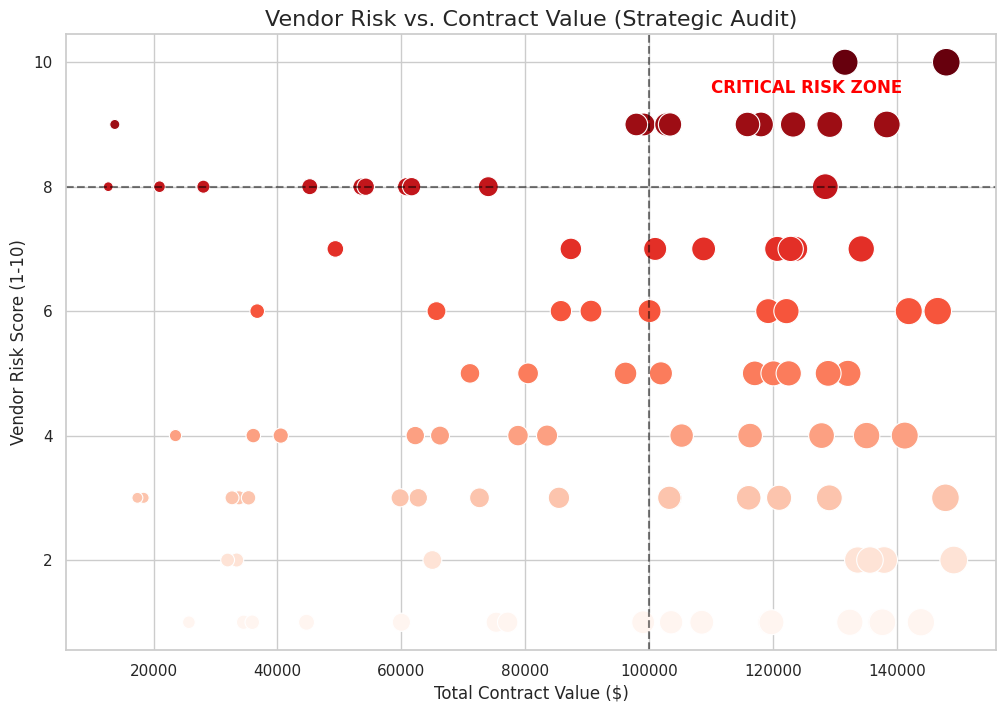

--- ARCHITECT ALERT: Risk Map Deployment Successful ---


In [16]:
plt.figure(figsize=(12, 8))

# Create the Scatter Plot
# X-axis = Contract Value, Y-axis = Risk Score
scatter = sns.scatterplot(data=df, x='contract_value', y='risk_score',
                          hue='risk_score', size='contract_value',
                          palette='Reds', sizes=(50, 400), legend=None)

# Add a 'Danger Zone' threshold line
plt.axhline(y=8, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=100000, color='black', linestyle='--', alpha=0.5)

# Label the "Danger Zone"
plt.text(110000, 9.5, 'CRITICAL RISK ZONE', color='red', fontweight='bold')

# Add Labels and Title
plt.title('Vendor Risk vs. Contract Value (Strategic Audit)', fontsize=16)
plt.xlabel('Total Contract Value ($)', fontsize=12)
plt.ylabel('Vendor Risk Score (1-10)', fontsize=12)

plt.show()
print("--- ARCHITECT ALERT: Risk Map Deployment Successful ---")